In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/raw/upi_transactions_2024.csv")

In [3]:
df["timestamp"].head(10)

0    2024-10-08 15:17:28
1    2024-04-11 06:56:00
2    2024-04-02 13:27:18
3    2024-01-07 10:09:17
4    2024-01-23 19:04:23
5    2024-10-07 22:32:07
6    2024-02-08 10:25:57
7    2024-10-27 18:47:02
8    2024-11-21 09:39:16
9    2024-11-11 15:58:56
Name: timestamp, dtype: str

In [4]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   transaction id      250000 non-null  str           
 1   timestamp           250000 non-null  datetime64[us]
 2   transaction type    250000 non-null  str           
 3   merchant_category   250000 non-null  str           
 4   amount (INR)        250000 non-null  int64         
 5   transaction_status  250000 non-null  str           
 6   sender_age_group    250000 non-null  str           
 7   receiver_age_group  250000 non-null  str           
 8   sender_state        250000 non-null  str           
 9   sender_bank         250000 non-null  str           
 10  receiver_bank       250000 non-null  str           
 11  device_type         250000 non-null  str           
 12  network_type        250000 non-null  str           
 13  fraud_flag          250000 non-null  int

In [6]:
df["transaction_hour"] = df["timestamp"].dt.hour

In [7]:
df["transaction_hour"].head(20)

0     15
1      6
2     13
3     10
4     19
5     22
6     10
7     18
8      9
9     15
10    20
11    10
12    20
13     0
14    12
15    15
16     7
17    18
18    22
19    18
Name: transaction_hour, dtype: int32

In [8]:
(df["transaction_hour"] == df["hour_of_day"]).all()

np.True_

In [9]:
mismatch = df[df["transaction_hour"]!=df["hour_of_day"]]
mismatch.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,transaction_hour


In [10]:
df["tansaction_day"] = df["timestamp"].dt.day_name()
df["tansaction_day"].head()

0     Tuesday
1    Thursday
2     Tuesday
3      Sunday
4     Tuesday
Name: tansaction_day, dtype: str

In [11]:
(df["tansaction_day"] == df["day_of_week"]).all()

np.True_

In [12]:
df["weekend"] = (df["tansaction_day"].isin(["Saturday", "Sunday"]).astype(int))

In [13]:
df["weekend"].head()

0    0
1    0
2    0
3    1
4    0
Name: weekend, dtype: int64

In [14]:
(df["weekend"] == df["is_weekend"]).all()

np.True_

In [15]:
df["business_hour"] = ((df["transaction_hour"]>=9) & (df["transaction_hour"]<= 18)).astype(int)

In [16]:
df["business_hour"].head()

0    1
1    0
2    1
3    1
4    0
Name: business_hour, dtype: int64

In [17]:
df["night_transaction"] = ((df["transaction_hour"]>=0)&(df["transaction_hour"]<=5)).astype(int)

In [18]:
df["night_transaction"].head()

0    0
1    0
2    0
3    0
4    0
Name: night_transaction, dtype: int64

In [19]:
df["night_transaction"].value_counts()

night_transaction
0    238380
1     11620
Name: count, dtype: int64

In [20]:
df["night_transaction"].value_counts(normalize=True)*100

night_transaction
0    95.352
1     4.648
Name: proportion, dtype: float64

In [21]:
pd.crosstab(df["night_transaction"], df["fraud_flag"], normalize = "index")*100

fraud_flag,0,1
night_transaction,,
0,99.808289,0.191711
1,99.802065,0.197935


In [22]:
night_fraud_table = pd.crosstab(
    df["night_transaction"],
    df["fraud_flag"],
    normalize="index"
) * 100

night_fraud_table = night_fraud_table.rename(
    index={0: "Non-night", 1: "Night"},
    columns={0: "Genuine %", 1: "Fraud %"}
)

night_fraud_table

fraud_flag,Genuine %,Fraud %
night_transaction,,
Non-night,99.808289,0.191711
Night,99.802065,0.197935


In [23]:
pd.crosstab(
    df["weekend"],
    df["fraud_flag"],
    normalize = "index"
)*100

fraud_flag,0,1
weekend,,
0,99.811377,0.188623
1,99.799543,0.200457


In [24]:
pd.crosstab(
    df["merchant_category"],
    df["fraud_flag"],
    normalize = "index"
)*100

fraud_flag,0,1
merchant_category,,
Education,99.789418,0.210582
Entertainment,99.801025,0.198975
Food,99.805146,0.194854
Fuel,99.808483,0.191517
Grocery,99.811872,0.188128
Healthcare,99.834163,0.165837
Other,99.798614,0.201386
Shopping,99.792448,0.207552
Transport,99.786123,0.213877


In [25]:
df.groupby("fraud_flag")["amount (INR)"].describe()

,count,mean,std,min,25%,50%,75%,max
fraud_flag,,,,,,,,
0,249520.0,1311.395391,1847.210565,10.0,288.0,629.0,1596.0,42099.0
1,480.0,1499.231250,2240.707939,28.0,260.0,618.5,1673.5,17718.0


In [26]:
import matplotlib.pyplot as plt

<Figure size 800x600 with 0 Axes>

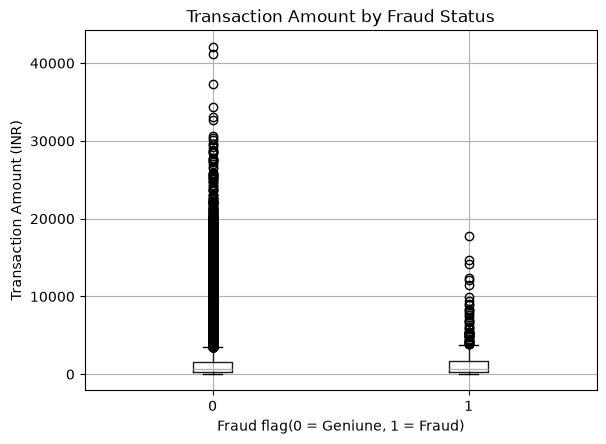

In [27]:
plt.figure(figsize=(8,6))

df.boxplot(column = "amount (INR)", by = "fraud_flag")

plt.title("Transaction Amount by Fraud Status")
plt.suptitle("")
plt.xlabel("Fraud flag(0 = Geniune, 1 = Fraud)")
plt.ylabel("Transaction Amount (INR)")

plt.show()

In [28]:
#Transaction Amount Outlier Analysis

### Objective

#The box plot shows many outliers in both fraud and genuine transactions.
#Since the dataset is highly imbalanced, comparing the number of outliers is misleading.

#Instead, we calculate the percentage of outliers in each class using the IQR method.

In [55]:
genuine_df = df[df["fraud_flag"] == 0]

In [56]:
genuine_df.head(10)

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,transaction_hour,tansaction_day,weekend,business_hour,night_transaction
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,...,4G,0,15,Tuesday,0,15,Tuesday,0,1,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,...,4G,0,6,Thursday,0,6,Thursday,0,0,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,...,4G,0,13,Tuesday,0,13,Tuesday,0,1,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,...,5G,0,10,Sunday,1,10,Sunday,1,1,0
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,...,WiFi,0,19,Tuesday,0,19,Tuesday,0,0,0
5,TXN0000000006,2024-10-07 22:32:07,P2P,Food,91,SUCCESS,36-45,18-25,Karnataka,IndusInd,...,3G,0,22,Monday,0,22,Monday,0,0,0
6,TXN0000000007,2024-02-08 10:25:57,P2P,Other,314,SUCCESS,36-45,18-25,Telangana,HDFC,...,4G,0,10,Thursday,0,10,Thursday,0,1,0
7,TXN0000000008,2024-10-27 18:47:02,P2P,Utilities,264,SUCCESS,46-55,36-45,Maharashtra,Yes Bank,...,5G,0,18,Sunday,1,18,Sunday,1,1,0
8,TXN0000000009,2024-11-21 09:39:16,P2P,Other,887,SUCCESS,46-55,36-45,Maharashtra,Kotak,...,4G,0,9,Thursday,0,9,Thursday,0,1,0
9,TXN0000000010,2024-11-11 15:58:56,P2M,Grocery,3260,SUCCESS,46-55,18-25,Delhi,SBI,...,4G,0,15,Monday,0,15,Monday,0,1,0


In [57]:
genuine_df.shape

(249520, 22)

In [58]:
fraud_df = df[df["fraud_flag"] == 1]

In [59]:
fraud_df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,transaction_hour,tansaction_day,weekend,business_hour,night_transaction
740,TXN0000000741,2024-10-30 17:37:20,Recharge,Healthcare,361,SUCCESS,18-25,18-25,Karnataka,SBI,...,5G,1,17,Wednesday,0,17,Wednesday,0,1,0
1228,TXN0000001229,2024-06-22 00:21:52,P2P,Fuel,479,SUCCESS,26-35,36-45,Karnataka,SBI,...,4G,1,0,Saturday,1,0,Saturday,1,0,1
2777,TXN0000002778,2024-06-12 19:46:25,P2P,Food,162,SUCCESS,18-25,36-45,Gujarat,PNB,...,4G,1,19,Wednesday,0,19,Wednesday,0,0,0
3761,TXN0000003762,2024-01-30 19:57:42,P2M,Transport,754,SUCCESS,26-35,36-45,Karnataka,ICICI,...,5G,1,19,Tuesday,0,19,Tuesday,0,0,0
3962,TXN0000003963,2024-11-28 21:36:02,P2P,Healthcare,402,SUCCESS,26-35,36-45,Maharashtra,Yes Bank,...,4G,1,21,Thursday,0,21,Thursday,0,0,0


In [60]:
fraud_df.shape

(480, 22)

## Step 1: Calculate Quartiles

#### To identify outliers fairly within each class, we first calculate the first quartile (Q1) and third quartile (Q3) of the transaction amount. 
#### These values are then used to compute the Interquartile Range (IQR), which forms the basis of the IQR outlier detection method.

In [61]:
q1 = genuine_df["amount (INR)"].quantile(0.25)

In [62]:
print(q1)

288.0


In [63]:
q3 = genuine_df["amount (INR)"].quantile(0.75)
print(q3)

1596.0


In [64]:
iqr = q3-q1
print(iqr)

1308.0
